# load simulations

In [125]:
%load_ext autoreload
%autoreload 2
from pydeconv.utils import *
from pydeconv.pydeconv_sims import *
import numpy as np
import mne

# %matplotlib qt 
n_seconds = 1000        # Duration of the signal in seconds
sfreq = 500            # Sampling frequency in Hz
sig = EEGSimulator(n_seconds, sfreq)
# transition probabilities
W_matrix = [[0, 0.45, 0.45, 0.1],
            [0.9, 0, 0 , .1],
            [0.9, 0, 0,.1],
            [.33,.33,.33,0]]
kernels = {
            0: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.05, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            1: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.05, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            2: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.07, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            3: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.07, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            'modulation': {'ker_idx2mod': 1, 'mod': 'linear','dist': 'uniform', 'lims': [100, 600]}
        }

sig.create_isi_pdf(0, sample_size=100, lims=[.01, .15], dist_type='skewed', mode=.05, skew=0, scale=.01)
sig.create_isi_pdf(1, sample_size=100, lims=[.1, .6], dist_type='skewed', mode=.3, skew=2, scale=.05)
sig.create_isi_pdf(2, sample_size=100, lims=[.1, .6], dist_type='skewed', mode=.3, skew=2, scale=.05)
sig.create_isi_pdf(3, sample_size=100, lims=[.1, .6], dist_type='uniform')


# sig.combine_isi_pdf
# sig.plot_isi_pdf(0)
# sig.plot_isi_pdf(1)

################
sig.simulate(noise="brown",erp_ker=kernels,w_matrix=W_matrix)

# create evts

# Copy and modify the event data
evts = sig.evts.copy()

# Set the event type to filter (event_id 1 for example)
event_id1 = 1
event_id2 = 2

# Filter events where `type == event_id`
filtered_evts = evts.loc[(evts['type'] == event_id1) | (evts['type'] == event_id2)]

# Get the number of filtered events
n_events = len(filtered_evts)

# Ensure that latencies are integer values
latencies = filtered_evts['latency'].values.astype(int)

# Create the events array for MNE
# Column 1: Latencies
# Column 2: Zeros (assuming no previous event values, hence zeros)
# Column 3: Event types (all set to 1 since filtered for `event_id`)
mne_events = np.column_stack((latencies,
                              np.zeros(n_events, dtype=int),
                              np.ones(n_events, dtype=int)))

# Print or use `mne_events` as needed
print(mne_events[:5])
#create RAW
# Creating simulated RAW

# Parameters

n_samples = n_seconds * sfreq  # Total number of samples
n_channels = 1         # Number of channels (virtual channel)

# Create random data for the virtual channel (shape: [n_samples])
data = sig.data

# Reshape the data to be 2D (n_channels, n_samples)
data = data.reshape((n_channels, n_samples))

# Create MNE info object
ch_names = ['VirtualEEG']  # Name of the virtual channel
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

# Create the Raw object from the reshaped data array
raw = mne.io.RawArray(data, info)

evts['type'].value_counts()

# Update 'effect' column
evts['effect'] = evts['type'].apply(lambda x: True if x == 2 else False if x == 1 else np.nan)

# Replace all 2s with 1s in 'type' column
evts['type'] = evts['type'].replace(2, 1)
evts['type'].value_counts()
columns = {'latencies':latencies,	'type':'type','categorical':'categorical','continuous':'continuous'}
# evts.rename(columns=columns, inplace=True)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[[  4   0   1]
 [ 67   0   1]
 [141   0   1]
 [189   0   1]
 [247   0   1]]
Creating RawArray with float64 data, n_channels=1, n_times=500000
    Range : 0 ... 499999 =      0.000 ...   999.998 secs
Ready.


## SK with simulation

Analyzing data with model: testingSims
Time range: -0.2 to 0.6
Solver: ridge

Model Name: testingSims
First Intercept Event Type: 1
Second Intercept Event Type: 0
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 1

Model Description:
Intercept: True
Additive Features: ['effect']
Interactions: None


Original Design Matrix Shape:
X_design shape: (500000, 1203)
y_data shape: (500000, 1)


Training completed in 0:00:03.328644
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.


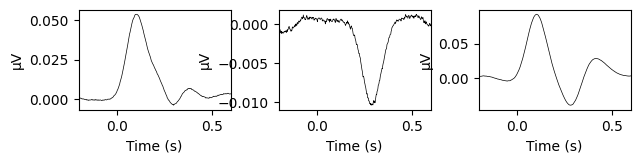

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import torch
import numpy as np
from scipy import sparse

def normalize_data(X, y):
    """Center the data like sklearn"""
    # Convert sparse matrix to dense numpy array if necessary
    if sparse.issparse(X):
        X = X.toarray()
    if sparse.issparse(y):
        y = y.toarray()
    
    # Ensure X and y are numpy arrays
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    
    # Compute mean
    X_mean = X.mean(axis=0)
    y_mean = y.mean(axis=0)
    
    # Compute standard deviation
    X_std = X.std(axis=0, ddof=1)
    
    # Prevent division by zero
    X_std = np.where(X_std == 0, 1.0, X_std)
    
    # Center and scale X, only center y
    X_normalized = (X - X_mean) / (X_std + 1e-8)
    y_normalized = y - y_mean
    
    # Convert to torch tensors if needed
    X_normalized = torch.tensor(X_normalized, dtype=torch.float32)
    y_normalized = torch.tensor(y_normalized, dtype=torch.float32)
    
    return X_normalized, y_normalized

def ridge_loss_custom(rERP_model,X, y):
    """
    Implement loss exactly like sklearn's Ridge:
    Loss = (1/(2*n_samples)) * ||y - Xw||^2 + (alpha/(2*n_samples)) * ||w||^2
    """
    n_samples = y.shape[0]
    
    # MSE term
    mse_loss = torch.sum((rERP_model.predict(X) - y) ** 2) / (2 * n_samples)
    
    # L2 regularization term (exclude bias from regularization like sklearn)
    ridge_penalty = (rERP_model.estimator.alpha / (2 * n_samples)) * torch.sum(rERP_model.coef_ ** 2)
    
    return mse_loss + ridge_penalty, mse_loss.item(), ridge_penalty.item()

# Note: The rest of the code seems to depend on context and other imported modules 
# that are not shown here (pydeconv, config4test, etc.). I'm making some assumptions.

# Assuming these are defined elsewhere in your code
from pydeconv import *
import config4test
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

# Main script
settings = analyze_data(config4test)
features = evts
# raw = raw (commented out in original code)

# Initialize the model
rERP_model = PyDeconv(settings=settings, features=features, eeg=raw, normalize=True)
X_design = rERP_model.create_matrix()
y_data = rERP_model.get_nonzero_data()

# Normalize data
X_design, y_data = normalize_data(X_design, y_data)

# Model Selection
solver = rERP_model.estimator
num_folds = 5
alphas = np.linspace(5, 500, 20)
param_grid = {'alpha': alphas.tolist()}

# Uncomment if you want to use grid search
# kf = KFold(n_splits=num_folds)
# grid_search = GridSearchCV(estimator=solver,
#                            param_grid=param_grid,
#                            scoring='neg_mean_squared_error',
#                            cv=kf, 
#                            verbose=5)
# grid_search.fit(X_design, y_data)
# best_model = grid_search.best_estimator_

# Set alpha manually or use best alpha from grid search
rERP_model.estimator.set_params(alpha=5)
rERP_model.fit(X_design, y_data)

# Plotting
rERP_model.plot_coefs(top_topos=False)
plt.show()

In [31]:
(128-198 )/500

-0.14

In [21]:
rERP_model.eeg

<RawArray | 1 x 25000 (50.0 s), ~202 kB, data loaded>

## Torch

In [14]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import timedelta

class RidgeDeconvolution:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=100, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = {'total': [], 'mse': [], 'ridge': []}
        self.training_time = None
        
        # Initialize weights closer to zero
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)
        nn.init.normal_(self.linear.weight, mean=0.0, std=0.01)
        if fit_intercept:
            nn.init.zeros_(self.linear.bias)
        
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def normalize_data(self, X, y):
        """Center the data like sklearn"""
        if self.X_mean is None:
            self.X_mean = X.mean(dim=0, keepdim=True)
            self.y_mean = y.mean(dim=0, keepdim=True)
            
            # Only scale X like sklearn's Ridge
            self.X_std = torch.sqrt(torch.sum((X - self.X_mean)**2, dim=0, keepdim=True) / X.shape[0])
            self.y_std = None  # Don't scale y
        
        # Center and scale X, only center y
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
        y_normalized = y - self.y_mean if self.fit_intercept else y
        
        return X_normalized, y_normalized

    def loss(self, predictions, y):
        """
        Implement loss exactly like sklearn's Ridge:
        Loss = (1/(2*n_samples)) * ||y - Xw||^2 + (alpha/(2*n_samples)) * ||w||^2
        """
        n_samples = y.shape[0]
        
        # MSE term
        mse_loss = torch.sum((predictions - y) ** 2) / (2 * n_samples)
        
        # L2 regularization term (exclude bias from regularization like sklearn)
        ridge_penalty = (self.alpha / (2 * n_samples)) * torch.sum(self.linear.weight ** 2)
        
        return mse_loss + ridge_penalty, mse_loss.item(), ridge_penalty.item()

    def fit(self, X, y, epochs=1000, lr=0.01):
        start_time = time.time()

        # Ensure input is a PyTorch tensor and stays on CPU
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        if not isinstance(y, torch.Tensor):
            y = torch.tensor(y, dtype=torch.float32)

        # Normalize data (still on CPU)
        X, y = self.normalize_data(X, y)

        n_samples = X.shape[0]

        # Use Adam optimizer
        optimizer = optim.Adam(self.linear.parameters(), lr=lr, eps=1e-8)

        for epoch in range(epochs):
            total_loss = 0
            total_mse = 0
            total_ridge = 0
            num_batches = 0

            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)

                # Move batch to GPU, keeping rest on CPU
                X_batch = X[i:batch_end].to(self.device, non_blocking=True)
                y_batch = y[i:batch_end].to(self.device, non_blocking=True)

                optimizer.zero_grad()
                predictions = self.linear(X_batch)

                loss, mse, ridge = self.loss(predictions, y_batch)
                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.linear.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += loss.item() * (batch_end - i)
                total_mse += mse * (batch_end - i)
                total_ridge += ridge * (batch_end - i)
                num_batches += 1

                # Explicitly delete batch and clear cache
                del X_batch, y_batch, predictions
                torch.cuda.empty_cache()

            avg_loss = total_loss / n_samples
            avg_mse = total_mse / n_samples
            avg_ridge = total_ridge / n_samples

            self.loss_history['total'].append(avg_loss)
            self.loss_history['mse'].append(avg_mse)
            self.loss_history['ridge'].append(avg_ridge)

            if epoch > 10 and abs(self.loss_history['total'][-1] - self.loss_history['total'][-2]) < 1e-7:
                print(f"Converged at epoch {epoch}")
                break

            if epoch % 10 == 0:
                elapsed = time.time() - start_time
                eta = (elapsed / (epoch + 1)) * (epochs - epoch - 1)
                print(f"Epoch {epoch}/{epochs}, Total Loss: {avg_loss:.6f}, "
                    f"MSE: {avg_mse:.6f}, Ridge: {avg_ridge:.6f}, "
                    f"Elapsed: {timedelta(seconds=int(elapsed))}, "
                    f"ETA: {timedelta(seconds=int(eta))}")

        self.training_time = time.time() - start_time
        print(f"\nTraining completed in {timedelta(seconds=self.training_time)}")


    def predict(self, X):
        """Predict like sklearn's Ridge"""
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        
        X = X.to(self.device)
        
        self.linear.eval()
        with torch.no_grad():
            X_normalized = (X - self.X_mean)/ (self.X_std + 1e-8)
            predictions = self.linear(X_normalized)
            if self.fit_intercept:
                predictions = predictions + self.y_mean
            
        return predictions.cpu().numpy()

    def get_coefficients(self):
        """Get coefficients in the original scale like sklearn"""
        with torch.no_grad():
            # Get weights
            weights = self.linear.weight.cpu()
            
            # Rescale weights
            scaled_weights = weights/ (self.X_std + 1e-8).cpu()
            
            # Get intercept if fitted
            if self.fit_intercept:
                intercept = self.y_mean.cpu() - torch.mm(self.X_mean.cpu(), scaled_weights.t())
            else:
                intercept = torch.zeros(self.linear.out_features)
            
            return scaled_weights.numpy(), intercept.numpy()

    def plot_learning_curve(self, log_scale=True):
        """
        Plot the learning curve showing total loss, MSE, and ridge penalty components
        """
        plt.figure(figsize=(12, 6))
        epochs = range(1, len(self.loss_history['total']) + 1)
        
        plt.plot(epochs, self.loss_history['total'], 'b-', label='Total Loss')
        plt.plot(epochs, self.loss_history['mse'], 'g-', label='MSE Loss')
        plt.plot(epochs, self.loss_history['ridge'], 'r-', label='Ridge Penalty')
        
        plt.title(f'Learning Curve\nTraining Time: {timedelta(seconds=int(self.training_time))}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        
        if log_scale:
            plt.yscale('log')
        
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()
        
        # Add training details as text
        details = (f'α={self.alpha}\n'
                  f'Batch Size={self.batch_size}\n'
                  f'Device={self.device}\n'
                  f'Final Loss={self.loss_history["total"][-1]:.6f}')
        plt.text(0.02, 0.98, details, 
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
    def custom_r2_score(self, X, y):
            """
            Compute the R^2 (coefficient of determination) for the model.
            
            Parameters:
            -----------
            X : array-like of shape (n_samples, n_features)
                Test samples.
            y : array-like of shape (n_samples,) or (n_samples, n_targets)
                True values for X.
                
            Returns:
            --------
            score : float or ndarray
                R^2 of self.predict(X) with respect to y.
                
            Notes:
            ------
            R^2 = 1 - (SS_res / SS_tot)
            """
            # Ensure inputs are tensors on the CPU
            if not isinstance(X, torch.Tensor):
                X = torch.tensor(X, dtype=torch.float32, device="cpu")
            if not isinstance(y, torch.Tensor):
                y = torch.tensor(y, dtype=torch.float32, device="cpu")
            
            # Obtain predictions (ensured to return on CPU in self.predict)
            y_pred = self.predict(X)  # Returns a NumPy array
            y_pred = torch.tensor(y_pred, dtype=torch.float32, device="cpu")
            
            # Compute the mean of true values
            y_mean = torch.mean(y, dim=0)
            
            # Compute SS_res and SS_tot
            ss_res = torch.sum((y - y_pred) ** 2, dim=0)  # Residual sum of squares
            ss_tot = torch.sum((y - y_mean) ** 2, dim=0)  # Total sum of squares
            
            # Calculate R²
            r2 = 1 - (ss_res / (ss_tot + 1e-8))  # Add small value to avoid division by zero
            
            # Return R² as a NumPy array
            return r2.numpy().mean()


        
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Generate or load your design matrix for deconvolution (X_design)
    # and your response vector/matrix (y_data), ensuring that X_design 
    # properly reflects event separation with a Toeplitz structure if needed.
    X_torch = torch.tensor(X_design).float().to(device)  # Convert to dense PyTorch tensor
    y_torch = torch.tensor(y_data).float().to(device)

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=5, fit_intercept=False, batch_size=20000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=8,lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)
    # coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    coeffs = torch_ridge.get_coefficients()[0]
    rERP_model.coef_ =  coeffs
    # # Predictions should now have shape (13000, 3)
    # torch_predictions = torch_ridge.predict(X_torch)
    rERP_model.plot_coefs(top_topos=False)


NameError: name 'X_design' is not defined

In [49]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Convert inputs to torch tensors if needed
if not isinstance(X_design, torch.Tensor):
    X_design = torch.tensor(X_design.todense(), dtype=torch.float32)
if not isinstance(y_data, torch.Tensor):
    y_data = torch.tensor(y_data, dtype=torch.float32)
# n_samples = X_design.shape[0]
# i = 2
# batch_end = min(i + 200000, n_samples)

# # Move batch to device
# X_batch = X_design[i:batch_end].to(device)
# y_batch = y_data[i:batch_end].to(device)




Epoch 0/20, Total Loss: 0.140777, MSE: 0.140763, Ridge: 0.000014, Elapsed: 0:00:00, ETA: 0:00:01
Epoch 10/20, Total Loss: 0.027240, MSE: 0.027168, Ridge: 0.000071, Elapsed: 0:00:00, ETA: 0:00:00

Training completed in 0:00:00.297262


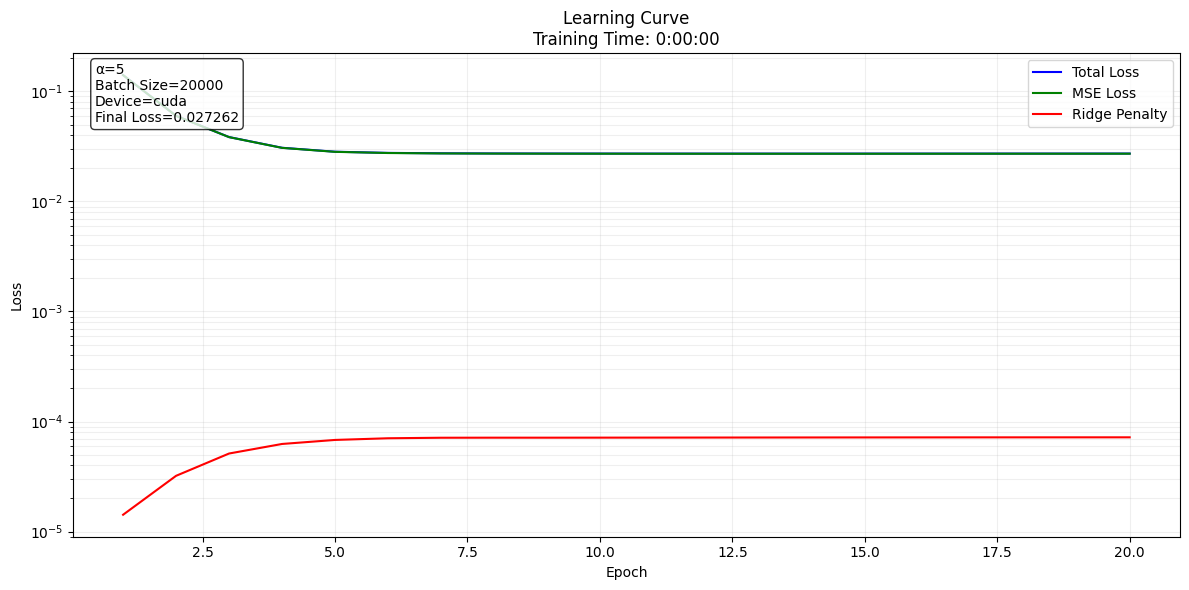

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.


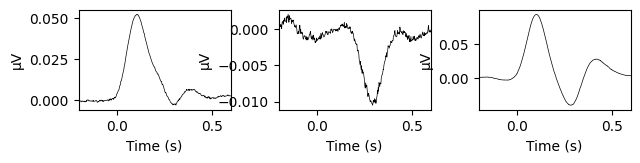

In [28]:

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=5, fit_intercept=False, batch_size=20000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=20, lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    # torch_predictions = torch_ridge.predict(X_torch)
    # print("Predictions shape:", torch_predictions.shape)
    # coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    coeffs = torch_ridge.get_coefficients()[0]
    rERP_model.coef_ =  coeffs
    # # Predictions should now have shape (13000, 3)
    # torch_predictions = torch_ridge.predict(X_torch)
    rERP_model.plot_coefs(top_topos=False)


## Trying to define the model with Conv1D

/tmp/ipykernel_567475/281470335.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_torch = torch.tensor(X_design).float().to(device)  # Convert to dense PyTorch tensor
/tmp/ipykernel_567475/281470335.py:99: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_torch = torch.tensor(y_data).float().to(device)
/tmp/ipykernel_567475/281470335.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X.todense(), dtype=torch.float32, device=self.device) if hasattr(X, "todense") else torch.tensor(X, dtype=torch.float32, device=self.de

Epoch 1/8, Loss: 0.499376
Epoch 2/8, Loss: 0.236222
Epoch 3/8, Loss: 0.223422
Epoch 4/8, Loss: 0.228834
Epoch 5/8, Loss: 0.231479
Epoch 6/8, Loss: 0.229483
Epoch 7/8, Loss: 0.228105
Epoch 8/8, Loss: 0.227520


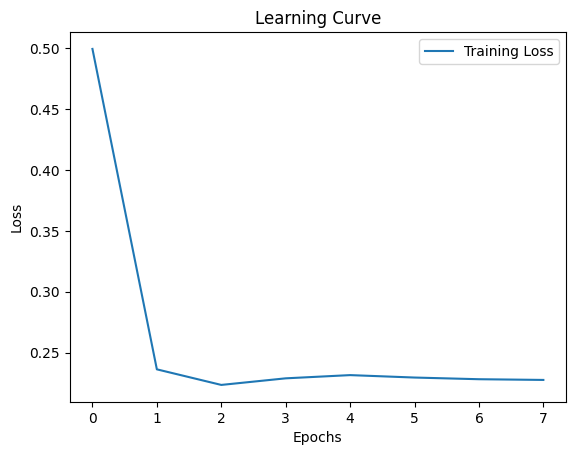

Predictions shape: (243517, 1)


/tmp/ipykernel_567475/281470335.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X.todense(), dtype=torch.float32, device=self.device) if hasattr(X, "todense") else torch.tensor(X, dtype=torch.float32, device=self.device)


NameError: name 'scaled_weights' is not defined

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import timedelta

class RidgeDeconvolution:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = []
        self.y_std = None

        # Define the linear model
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)

    def fit(self, X, y, epochs=1000, lr=0.01):
        n_samples = X.shape[0]
        
        # Convert to PyTorch tensors (handling sparse matrices correctly)
        X = torch.tensor(X.todense(), dtype=torch.float32, device=self.device) if hasattr(X, "todense") else torch.tensor(X, dtype=torch.float32, device=self.device)
        y = torch.tensor(y, dtype=torch.float32, device=self.device)

        # optimizer = optim.Adam(self.linear.parameters(), lr=lr)
        optimizer = optim.SGD(self.linear.parameters(), lr=lr, momentum=0.9, weight_decay=self.alpha)
        for epoch in range(epochs):
            indices = torch.randperm(n_samples)
            epoch_loss = 0.0
            num_batches = (n_samples + self.batch_size - 1) // self.batch_size

            

            avg_loss = epoch_loss / num_batches
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
            

    def model(self, x):
        return self.linear(x)

    def loss(self, predictions, y, n_samples):
        mse_loss = torch.mean((predictions - y) ** 2)
        # Only regularize weights, not bias
        ridge_penalty = (self.alpha / n_samples) * torch.sum(self.linear.weight ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        X = torch.tensor(X.todense(), dtype=torch.float32, device=self.device) if hasattr(X, "todense") else torch.tensor(X, dtype=torch.float32, device=self.device)
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

    def get_coefficients(self):
        """Get coefficients in the original scale like sklearn"""
        with torch.no_grad():
            # Get weights
            weights = self.linear.weight.cpu()
            
            # Rescale weights
            # scaled_weights = weights/ (self.X_std + 1e-8).cpu()
            
            # Get intercept if fitted
            if self.fit_intercept:
                intercept = self.y_mean.cpu() - torch.mm(self.X_mean.cpu(), scaled_weights.t())
            else:
                intercept = torch.zeros(self.linear.out_features)
            
            return scaled_weights.numpy(), intercept.numpy()

        
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Generate or load your design matrix for deconvolution (X_design)
    # and your response vector/matrix (y_data), ensuring that X_design 
    # properly reflects event separation with a Toeplitz structure if needed.
    X_torch = torch.tensor(X_design).float().to(device)  # Convert to dense PyTorch tensor
    y_torch = torch.tensor(y_data).float().to(device)

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=5, fit_intercept=False, batch_size=20000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=8,lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)
    # coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    coeffs = torch_ridge.get_coefficients()[0]
    rERP_model.coef_ =  coeffs
    # # Predictions should now have shape (13000, 3)
    # torch_predictions = torch_ridge.predict(X_torch)
    rERP_model.plot_coefs(top_topos=False)


In [15]:
settings

{'first_intercept_event_type': 1,
 'second_intercept_event_type': 0,
 'second_delay': None,
 'model_name': 'testingSims',
 'formula': 'y ~  1 + effect ',
 'tmin': -0.2,
 'tmax': 0.6,
 'use_splines': None,
 'analysis_outcome': 'example_outcome',
 'eeg_chns': 1,
 'parsed_formula': {'intercept': True,
  'interactions': None,
  'additive_features': ['effect']},
 'solver': 'ridge'}

In [16]:
features

,latency,type,categorical,continuous,effect
0,0.000000,0,NaN,NaN,NaN
1,7.532633,1,NaN,NaN,True
2,114.590002,0,NaN,NaN,NaN
3,112.913920,1,NaN,NaN,True
4,163.018868,0,NaN,NaN,NaN
...,...,...,...,...,...
4995,242983.945544,1,NaN,NaN,False
4996,243065.238700,0,NaN,NaN,NaN
4997,243069.082942,1,NaN,NaN,True
4998,243108.515657,0,NaN,NaN,NaN


In [126]:
def get_feature_vectors(settings, evts, raw):
    from .utils.pydeconv_functions import add_spline_features
    fst_intercept = settings['first_intercept_evet_type']
    snd_intercept = settings['second_intercept_evet_type']
    # create matrix of features as columns
    feature_matrix = np.zeros((len(evts), len(settings['feature_names'])))
    
    feature_matrix[:,0] = evts['type'].to_numpy() 
    feature_matrix          ['effect'].to_numpy()

feature_template = np.zeros(raw.n_times)


In [127]:
import numpy as np
import pandas as pd

def create_feature_vector(evts_df,column_to_filter,value,max_latency=None):
    """
    Creates a feature vector where a 1 is placed at latency positions where event type == 0.
    
    Parameters:
    -----------
    evts_df : pandas DataFrame
        DataFrame containing 'latency' and 'type' columns
    max_latency : int, optional
        Maximum length of the feature vector. If None, will use the maximum latency value in the DataFrame
    
    Returns:
    --------
    feature_vector : numpy array
        Vector with 1s at positions corresponding to latencies of events with type 0
    """
    # Filter events of type 0
    type_0_events = evts_df[evts_df[column_to_filter] == value]
    
    # Get latencies of type 0 events
    latencies = type_0_events['latency'].values
    
    # Determine maximum latency if not specified
    if max_latency is None:
        max_latency = int(evts_df['latency'].max()) + 1
    
    # Create feature vector initialized with zeros
    feature_vector = np.zeros(max_latency)
    
    # Set 1s at positions corresponding to latencies of type 0 events
    for lat in latencies:
        # Ensure latency is an integer and within bounds
        lat_idx = int(lat)
        if 0 <= lat_idx <= max_latency:
            feature_vector[lat_idx] = 1
    
    return feature_vector




In [128]:
def _delays(tmin, tmax, sfreq):
    """Convert a tmin/tmax in seconds to delays.

    Parameters
    ----------
    tmin : float
        Start time in seconds.
    tmax : float
        End time in seconds.
    sfreq : float
        Sampling frequency.

    Returns
    -------
    delays : array
        Delay indices.
    """
    # Convert seconds to samples
    delays = np.arange(int(np.round(tmin * sfreq)), int(np.round(tmax * sfreq) + 1))
    return delays
kernel_length =  len(_delays(-.2, .5, 500))



Using device: cuda
Starting training...
Epoch 100, Loss: 0.023940
Epoch 200, Loss: 0.017737
Epoch 300, Loss: 0.017267
Epoch 400, Loss: 0.017227
Epoch 500, Loss: 0.017220
Training completed in 5.67 seconds


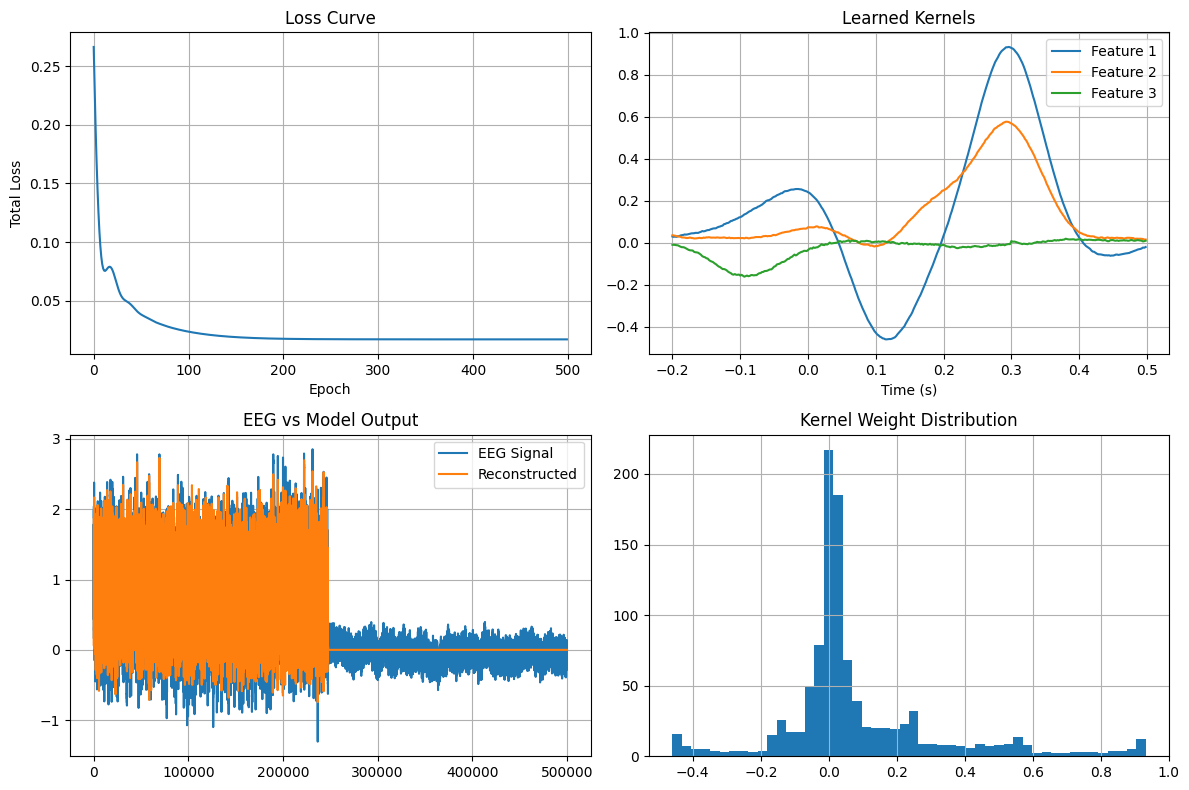

In [139]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import convolve

# ---- Helper Function for delays ----
def _delays(start, stop, sfreq):
    return np.arange(start, stop, 1/sfreq)

# ---- Example Setup ----
n_times = raw.n_times
y = raw.get_data()[0]  # Using one EEG channel for now

# Create mock feature vectors
delay_offset = len(_delays(-.2, 0, 500))
feature_vec1 = np.roll(create_feature_vector(evts, 'type', 0, n_times), 3*delay_offset)
feature_vec2 = np.roll(create_feature_vector(evts, 'type', 1, n_times), 3*delay_offset)
feature_vec3 = np.roll(create_feature_vector(evts, 'effect', True, n_times), 2*delay_offset)

X = np.stack([feature_vec1, feature_vec2, feature_vec3], axis=0)  # shape: (3, n_times)

# ---- Parameters ----
kernel_size = len(_delays(-.2, .5, 500))
pad = kernel_size - 1
num_epochs = 500
learning_rate = 0.01
alpha = 0  # Ridge regularization strength
n_samples = n_times

# ---- Device Setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---- Convert to torch and move to device ----
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 3, n_times)
X_padded = nn.functional.pad(X_tensor, (pad, pad))  # (1, 3, n_times + 2*pad)
target_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, n_times)

# ---- Model Definition ----
class MultiFeatureConvModel(nn.Module):
    def __init__(self, in_channels, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.in_channels = in_channels
        self.raw_weight = nn.Parameter(torch.empty(1, in_channels, kernel_size))
        nn.init.normal_(self.raw_weight, mean=0.0, std=0.05)

    def forward(self, x):
        # Flip the kernel to do proper convolution
        flipped_weight = torch.flip(self.raw_weight, dims=[-1])
        return nn.functional.conv1d(x, flipped_weight, bias=None)

model = MultiFeatureConvModel(in_channels=3, kernel_size=kernel_size).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# ---- Training Loop with Ridge Regularization ----
loss_history = []
best_loss = float('inf')
patience, patience_counter = 1000, 0

print("Starting training...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_padded)
    output_cropped = output[..., pad:pad+n_times]

    # mse_loss = criterion(output_cropped, target_tensor)

    # MSE term
    mse_loss = torch.sum((target_tensor - output_cropped) ** 2) / (2 * n_samples)
    
    # L2 regularization term (exclude bias from regularization like sklearn)
    ridge_penalty = (alpha / (2 * n_samples)) * torch.sum( model.raw_weight** 2)

    loss = mse_loss + ridge_penalty

    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    loss_history.append(current_loss)

    if current_loss < best_loss:
        best_loss = current_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {current_loss:.6f}")

print(f"Training completed in {time.time() - start_time:.2f} seconds")


with torch.no_grad():
    learned_kernels = model.raw_weight.squeeze().cpu().numpy()
    flipped_kernels = learned_kernels[:, ::-1]  # Flip for visualization to match signal processing style

# ---- Plotting ----
plt.figure(figsize=(12, 8))

# Loss Curve
plt.subplot(2, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.grid(True)

# Learned Kernels
plt.subplot(2, 2, 2)
times = _delays(-.2, .5, 500)
for i in range(3):
    plt.plot(times, flipped_kernels[i], label=f"Feature {i+1}")
plt.title("Learned Kernels")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

# Signal Comparison
with torch.no_grad():
    predicted = model(X_padded).squeeze().cpu().numpy()
predicted = predicted[pad:pad+n_times]

plt.subplot(2, 2, 3)
plt.plot(y, label="EEG Signal")
plt.plot(predicted, label="Reconstructed")
plt.legend()
plt.title("EEG vs Model Output")
plt.grid(True)

# Kernel Distribution
plt.subplot(2, 2, 4)
plt.hist(learned_kernels.flatten(), bins=50)
plt.title("Kernel Weight Distribution")
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
kept_idxs(pp, kernel_size=2,axis=1)

[0, 1, 2, 6, 7]

In [17]:
torch.tensor([1, 0, 0, 0, 1, 0, 0, 1,0,0,0,0,1]).shape

torch.Size([13])

In [32]:
pp = torch.tensor([[1, 0, 0, 0, 0, 0, 0, 1],
                   [0, 0, 0, 0, 0, 0, 0, 1],
                   [1, 1, 0, 0, 0, 0, 1, 1]])
pp.shape
np.nonzero(pp)
pp.shape

torch.Size([3, 8])

In [35]:
def kept_idxs(feature_tensor, kernel_size, axis=0):
    """
    Get the indices of the interesting samples to estimate the kernel in a vectorized way.
    Instead of creating individual intervals and merging them in Python loops,
    we use a difference-array approach:
      - For each event index, we add +1 at that index, and -1 at index+kernel_size.
      - Taking the cumulative sum recovers a mask that is positive for indices
        that fall into at least one window.
    
    Parameters:
    ----------
    feature_tensor : torch.Tensor
        A 1D tensor representing the feature (e.g., a binary marker for events).
    kernel_size : int
        The size of the kernel (i.e. the window length for each event).
    axis : int
        The axis along which to find the indices. Default is 0.
    
    Returns:
    -------
    kept_indices : list
        Sorted list of unique indices that fall in the union of all event windows.
    """
    # Convert tensor to NumPy (if not already) for efficient vectorized operations.
    feature_np = feature_tensor.cpu().numpy()
    
    # Find indices where feature is nonzero (i.e. event locations)
    event_idxs = np.nonzero(feature_np)[axis]
    if len(event_idxs) == 0:
        return []
    
    # Total number of samples
    L = feature_tensor.shape[axis]
    
    # Create a difference array of length L+1
    diff = np.zeros(L + 1, dtype=np.int32)
    
    # For each event, add 1 at the event index
    np.add.at(diff, event_idxs, 1)
    
    # And subtract 1 at index (event index + kernel_size), if within bounds.
    # Compute the end indices and clip them to L (since diff has length L+1)
    end_idxs = event_idxs + kernel_size
    valid_end = end_idxs[end_idxs <= L]
    np.add.at(diff, valid_end, -1)
    
    # Compute the cumulative sum over the difference array to get the window coverage.
    cumsum = np.cumsum(diff[:-1])
    
    # The indices with a positive value are within one or more windows.
    kept_indices = np.nonzero(cumsum > 0)[0]
    
    return kept_indices.tolist()


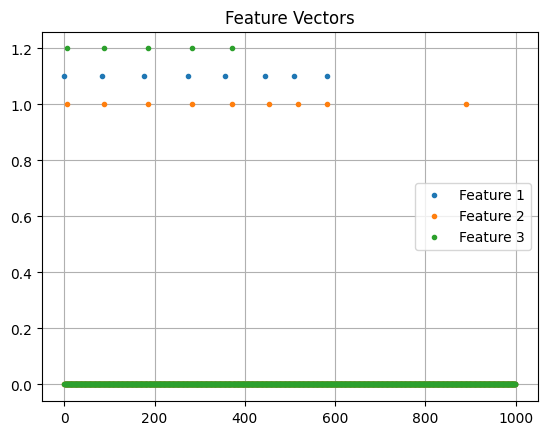

In [29]:
plt.plot(feature_vec1[:1000]*1.1, '.',label=f"Feature {1}")
plt.plot(feature_vec2[:1000], '.',label=f"Feature {2}")
plt.plot(feature_vec3[:1000]*1.2,'.', label=f"Feature {3}")
plt.title("Feature Vectors")
plt.legend()
plt.grid(True)
plt.show()  

## Deconvolution simulation using Conv1D

Using device: cuda
Starting training...
Epoch 100, Loss: 0.157791, MSE: 0.157791
Epoch 200, Loss: 0.098703, MSE: 0.098703
Epoch 300, Loss: 0.091511, MSE: 0.091511
Epoch 400, Loss: 0.090632, MSE: 0.090632
Epoch 500, Loss: 0.090523, MSE: 0.090523
Training completed in 5.87 seconds


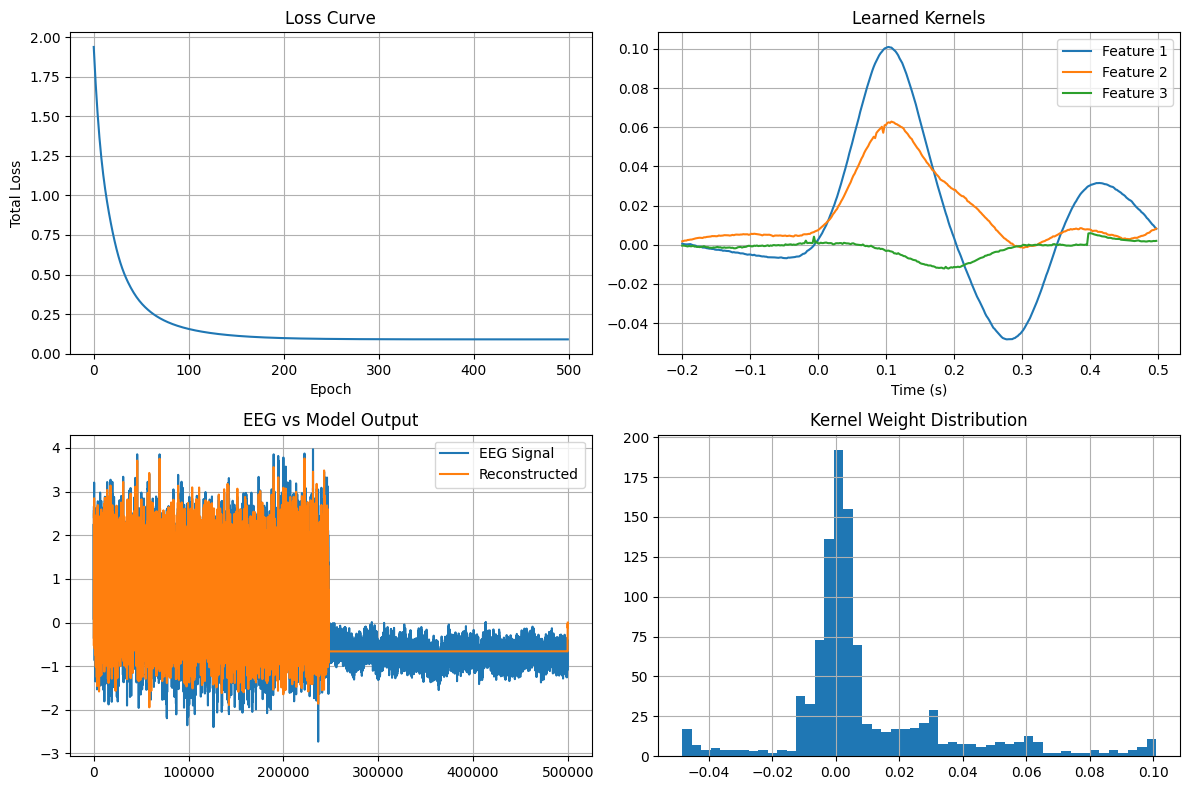

In [155]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import convolve

# ---- Helper Function for delays ----
def _delays(start, stop, sfreq):
    return np.arange(start, stop, 1/sfreq)

# ---- Example Setup ----
# Assuming raw and evts are defined elsewhere
n_times = raw.n_times
y = raw.get_data()[0]  # Using one EEG channel

# Normalize the target signal
y = (y - np.mean(y)) / np.std(y)



# ---- Parameters ----
kernel_size = len(_delays(-.2, .5, 500))
pad = kernel_size - 1
num_epochs = 500
learning_rate = 0.001  # Reduced learning rate
alpha = 1.0    # Reduced regularization
n_samples = n_times
# ---- Create Feature Vectors ----
# Create and normalize feature vectors
delay_offset = len(_delays(-.2, 0, 500))
feature_vec1 = np.roll(create_feature_vector(evts, 'type', 0, n_times), -delay_offset+pad)
feature_vec2 = np.roll(create_feature_vector(evts, 'type', 1, n_times), -delay_offset+pad)
feature_vec3 = np.roll(create_feature_vector(evts, 'effect', True, n_times), 3*delay_offset)
X = np.stack([feature_vec1, feature_vec2, feature_vec3], axis=0)
X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)
# ---- Device Setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---- Convert to torch ----
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)
X_padded = nn.functional.pad(X_tensor, (pad, pad))
target_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# ---- Model Definition ----
class MultiFeatureConvModel(nn.Module):
    def __init__(self, in_channels, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.in_channels = in_channels
        # Add bias and better initialization
        self.raw_weight = nn.Parameter(torch.zeros(1, in_channels, kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))
        nn.init.kaiming_normal_(self.raw_weight, mode='fan_in', nonlinearity='linear')

    def forward(self, x):
        flipped_weight = torch.flip(self.raw_weight, dims=[-1])
        out = nn.functional.conv1d(x, flipped_weight, bias=None)
        return out + self.bias  # Add bias term
    
    # Add constraint to prevent all-positive weights
    def get_kernels(self):
        return self.raw_weight.data

model = MultiFeatureConvModel(in_channels=3, kernel_size=kernel_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# ---- Training Loop ----
loss_history = []
best_loss = float('inf')
patience, patience_counter = 1000, 0

print("Starting training...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_padded)
    output_cropped = output[..., pad:pad+n_times]

    # Add correlation term to preserve signal shape
    mse_loss = criterion(output_cropped, target_tensor)
    corr_loss = -torch.corrcoef(torch.cat([output_cropped.flatten(), 
                                          target_tensor.flatten()]).reshape(2, -1))[0,1]
    # ridge_penalty = (alpha / n_samples) * torch.sum(model.raw_weight ** 2)
    loss = mse_loss #+ 0.1 * corr_loss# + ridge_penalty

    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    loss_history.append(current_loss)

    if current_loss < best_loss:
        best_loss = current_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {current_loss:.6f}, MSE: {mse_loss.item():.6f}")

print(f"Training completed in {time.time() - start_time:.2f} seconds")

# ---- Get Results ----
with torch.no_grad():
    learned_kernels = model.get_kernels().squeeze().cpu().numpy()
    flipped_kernels = learned_kernels

# ---- Plotting ----
plt.figure(figsize=(12, 8))

# Loss Curve
plt.subplot(2, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.grid(True)

# Learned Kernels
plt.subplot(2, 2, 2)
times = _delays(-.2, .5, 500)
for i in range(3):
    plt.plot(times, flipped_kernels[i], label=f"Feature {i+1}")
plt.title("Learned Kernels")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

# Signal Comparison
with torch.no_grad():
    predicted = model(X_padded).squeeze().cpu().numpy()
predicted = predicted[pad:pad+n_times]

plt.subplot(2, 2, 3)
plt.plot(y, label="EEG Signal")
plt.plot(predicted, label="Reconstructed")
plt.legend()
plt.title("EEG vs Model Output")
plt.grid(True)

# Kernel Distribution
plt.subplot(2, 2, 4)
plt.hist(learned_kernels.flatten(), bins=50)
plt.title("Kernel Weight Distribution")
plt.grid(True)

plt.tight_layout()
plt.show()

## Test toeplitz using scipy and Torch

In [142]:
import torch
import time

def toeplitz_lower_only_torch(vector: torch.Tensor, num_cols: int) -> torch.Tensor:
    """
    Create a lower-triangular Toeplitz matrix with a specified number of columns using PyTorch.
    All elements above the main diagonal are set to zero.

    Parameters
    ----------
    vector : torch.Tensor
        A 1D tensor of shape (n_rows,), used as the first column of the Toeplitz matrix.
        Must be a 1D tensor on CPU or GPU.

    num_cols : int
        Number of columns in the output Toeplitz matrix. Must be <= len(vector).

    Returns
    -------
    matrix : torch.Tensor
        A (n_rows, num_cols) lower-triangular Toeplitz matrix on the same device as `vector`.
    """
    n_rows = vector.shape[0]
    if num_cols > n_rows:
        raise ValueError("num_cols must be less than or equal to the length of the input vector.")

    device = vector.device
    # Indices for the target shape
    i = torch.arange(n_rows, device=device).unsqueeze(1)  # shape (n_rows, 1)
    j = torch.arange(num_cols, device=device).unsqueeze(0)  # shape (1, num_cols)
    idx = i - j  # shape (n_rows, num_cols)
    # print(idx)
    # print(i)
    # print(j)    
    # Get valid elements (i >= j), else set to zero
    toeplitz_mat = torch.where(idx >= 0, vector[idx], torch.zeros(1, device=device, dtype=vector.dtype))
    return toeplitz_mat



In [143]:
    i = torch.arange(10, device=device).unsqueeze(1)  # shape (n_rows, 1)
    j = torch.arange(1, device=device).unsqueeze(0)  # shape (1, num_cols)
    i-j

tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8],
        [9]], device='cuda:0')

In [153]:
t  = np.arange(15)
v = torch.tensor(t, device='cuda')
# %%timeit 
T = toeplitz_lower_only_torch(v, num_cols=10)
T

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 2,  1,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 3,  2,  1,  0,  0,  0,  0,  0,  0,  0],
        [ 4,  3,  2,  1,  0,  0,  0,  0,  0,  0],
        [ 5,  4,  3,  2,  1,  0,  0,  0,  0,  0],
        [ 6,  5,  4,  3,  2,  1,  0,  0,  0,  0],
        [ 7,  6,  5,  4,  3,  2,  1,  0,  0,  0],
        [ 8,  7,  6,  5,  4,  3,  2,  1,  0,  0],
        [ 9,  8,  7,  6,  5,  4,  3,  2,  1,  0],
        [10,  9,  8,  7,  6,  5,  4,  3,  2,  1],
        [11, 10,  9,  8,  7,  6,  5,  4,  3,  2],
        [12, 11, 10,  9,  8,  7,  6,  5,  4,  3],
        [13, 12, 11, 10,  9,  8,  7,  6,  5,  4],
        [14, 13, 12, 11, 10,  9,  8,  7,  6,  5]], device='cuda:0')

In [113]:
from scipy.linalg import toeplitz

def toeplitz_lower_only(vector: np.ndarray) -> np.ndarray:
    """
    Create a Toeplitz matrix with values only on the main and lower diagonals.
    The upper diagonal elements (strictly above the main diagonal) are set to zero.

    Parameters
    ----------
    vector : np.ndarray
        A 1D array of length `n`, used as the first column of the Toeplitz matrix.

    Returns
    -------
    matrix : np.ndarray
        A (n, n) Toeplitz matrix where elements above the main diagonal are zero.
    """
    vector = np.asarray(vector)
    r = np.zeros_like(vector)
    r[0] = vector[0]  # ensure the first row starts correctly
    return toeplitz(vector, r)
v = np.arange(10)
print(toeplitz_lower_only(v))


[[0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [2 1 0 0 0 0 0 0 0 0]
 [3 2 1 0 0 0 0 0 0 0]
 [4 3 2 1 0 0 0 0 0 0]
 [5 4 3 2 1 0 0 0 0 0]
 [6 5 4 3 2 1 0 0 0 0]
 [7 6 5 4 3 2 1 0 0 0]
 [8 7 6 5 4 3 2 1 0 0]
 [9 8 7 6 5 4 3 2 1 0]]


## Test Basic deconvolution using Torch

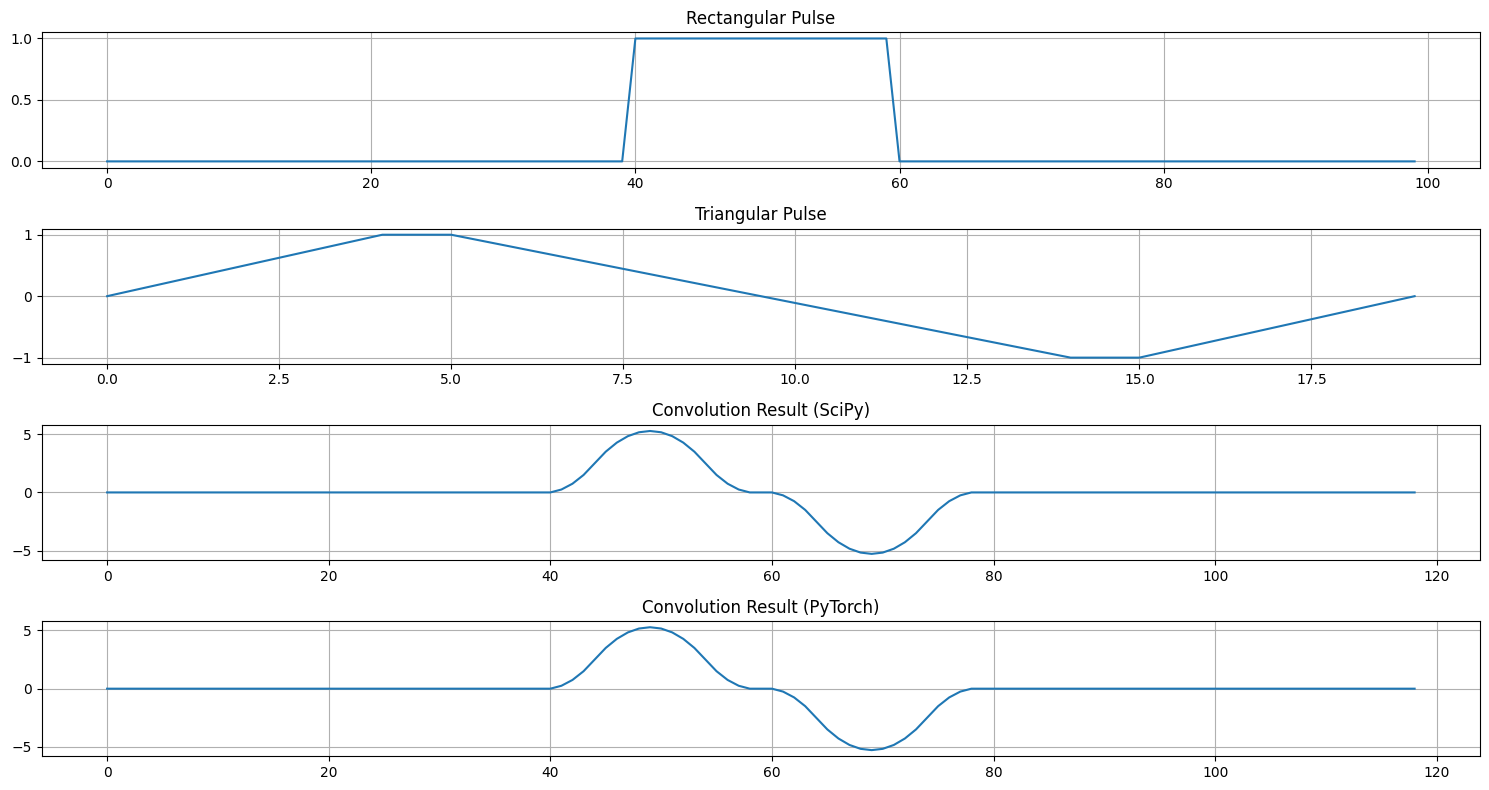

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
import torch
import torch.nn.functional as F

# Define a rectangular pulse
rect = np.zeros(100)
rect[40:60] = 1  # Pulse from index 40 to 59

# Define a triangular pulse
tri = np.concatenate([np.linspace(0, 1, 5), np.linspace(1, -1, 10), np.linspace(-1, 0, 5)])

# Perform the convolution with SciPy
conv_result = convolve(rect, tri, mode='full')

# ------------------ PyTorch Convolution ------------------ #
# Convert signals to torch tensors
rect_tensor = torch.tensor(rect, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 100)
tri_tensor = torch.tensor(tri[::-1].copy(), dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Flip for conv

# Perform convolution manually using F.conv1d with 'full' padding
padding = tri_tensor.shape[-1] - 1
torch_conv_result = F.conv1d(rect_tensor, tri_tensor, padding=padding)

# Remove batch/channel dimensions
torch_conv_result = torch_conv_result.squeeze().detach().numpy()

# ------------------ Plotting ------------------ #
# Create time axes
t_rect = np.arange(len(rect))
t_tri = np.arange(len(tri))
t_conv = np.arange(len(conv_result))
t_torch = np.arange(len(torch_conv_result))

plt.figure(figsize=(15, 8))

plt.subplot(4, 1, 1)
plt.plot(t_rect, rect)
plt.title("Rectangular Pulse")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t_tri, tri)
plt.title("Triangular Pulse")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t_conv, conv_result)
plt.title("Convolution Result (SciPy)")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t_torch, torch_conv_result)
plt.title("Convolution Result (PyTorch)")
plt.grid(True)

plt.tight_layout()
plt.show()


Epoch 50/2000, Loss: 0.072969
Epoch 100/2000, Loss: 0.017597
Epoch 150/2000, Loss: 0.006661
Epoch 200/2000, Loss: 0.003627
Epoch 250/2000, Loss: 0.002355
Epoch 300/2000, Loss: 0.001665
Epoch 350/2000, Loss: 0.001244
Epoch 400/2000, Loss: 0.000968
Epoch 450/2000, Loss: 0.000779
Epoch 500/2000, Loss: 0.000641
Epoch 550/2000, Loss: 0.000538
Epoch 600/2000, Loss: 0.000457
Epoch 650/2000, Loss: 0.000391
Epoch 700/2000, Loss: 0.000338
Epoch 750/2000, Loss: 0.000293
Epoch 800/2000, Loss: 0.000255
Epoch 850/2000, Loss: 0.000223
Epoch 900/2000, Loss: 0.000195
Epoch 950/2000, Loss: 0.000171
Epoch 1000/2000, Loss: 0.000150
Epoch 1050/2000, Loss: 0.000132
Epoch 1100/2000, Loss: 0.000117
Epoch 1150/2000, Loss: 0.000103
Epoch 1200/2000, Loss: 0.000091
Epoch 1250/2000, Loss: 0.000081
Epoch 1300/2000, Loss: 0.000071
Epoch 1350/2000, Loss: 0.000063
Epoch 1400/2000, Loss: 0.000056
Epoch 1450/2000, Loss: 0.000050
Epoch 1500/2000, Loss: 0.000044
Epoch 1550/2000, Loss: 0.000039
Epoch 1600/2000, Loss: 0.000

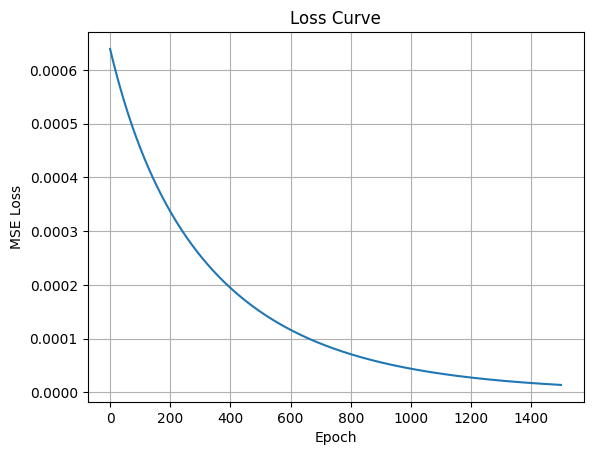

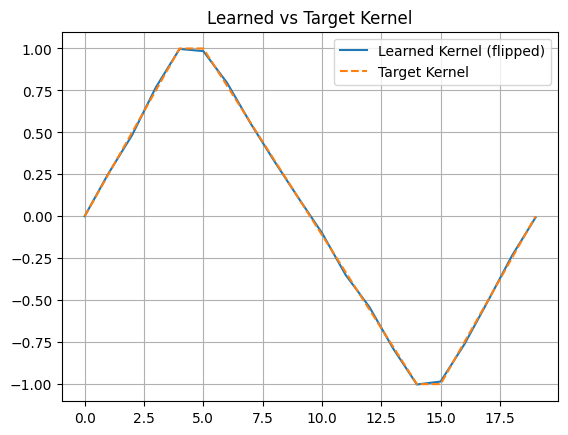

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# ----- Define the custom model -----
class LearnableConv1D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=kernel_size, bias=False)

    def forward(self, x):
        return self.conv(x)

# ----- Input and target signal -----
# Rectangular pulse
rect = np.zeros(100)
rect[40:60] = 1

# Triangular pulse (target kernel)
tri = np.concatenate([np.linspace(0, 1, 5), np.linspace(1, -1, 10), np.linspace(-1, 0, 5)])

# Compute the target output using numpy's full convolution
target_output = convolve(rect, tri, mode='full')

# ----- Torch Tensors -----
# Padding input to match 'full' convolution output
pad = len(tri) - 1
rect_tensor = torch.tensor(rect, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 100)
rect_tensor_padded = nn.functional.pad(rect_tensor, (pad, pad))  # (1, 1, 100 + 2*pad)
target_tensor = torch.tensor(target_output, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 119)

# ----- Model, optimizer, loss -----
kernel_size = len(tri)
model = LearnableConv1D(kernel_size=kernel_size)

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.MSELoss()

# ----- Training loop -----
num_epochs = 2000
loss_history = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(rect_tensor_padded)  # Output shape: (1, 1, 119)
    loss = criterion(output, target_tensor)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

# ----- Plot loss curve -----
plt.plot(loss_history[500:])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# ----- Plot learned vs true kernel -----
learned_kernel = model.conv.weight.detach().squeeze().numpy()
# Flip the learned kernel to compare with the true convolution kernel
learned_kernel_flipped = learned_kernel[::-1]

plt.plot(learned_kernel_flipped, label="Learned Kernel (flipped)")
plt.plot(tri, label="Target Kernel", linestyle="dashed")
plt.title("Learned vs Target Kernel")
plt.legend()
plt.grid(True)
plt.show()



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import mne
from pydeconv.utils import analyze_data

# Print initial GPU memory usage
if torch.cuda.is_available():
    print(f"Initial Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Initial Reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

# ============================ Helper Functions ============================

def create_feature_vector(evts_df, column_to_filter, value, max_latency=None, cond=None):
    filtered_events = evts_df[evts_df[column_to_filter] == value]
    if cond is not None:
        cond_col, cond_val = cond
        filtered_events = filtered_events[filtered_events[cond_col] == cond_val]
    if max_latency is None:
        max_latency = int(evts_df['latency'].max()) + 1
    feature_vector = np.zeros(max_latency)
    for lat in filtered_events['latency'].values:
        lat_idx = int(lat)
        if 0 <= lat_idx < max_latency:
            feature_vector[lat_idx] = 1
    return feature_vector

def _delays(tmin, tmax, sfreq):
    return np.arange(int(np.round(tmin * sfreq)), int(np.round(tmax * sfreq)) + 1)

# Safer normalization function
def safe_normalize(data, axis=0, eps=1e-8):
    mean = np.mean(data, axis=axis, keepdims=True)
    std = np.std(data, axis=axis, keepdims=True)
    # Add small epsilon to prevent division by zero
    std = np.maximum(std, eps)
    return (data - mean) / std

# ============================ Load Data ============================

data_path = "./example_data/"
settings = analyze_data()
features = pd.read_csv(data_path + "629959_full_metadata.csv") 
raw = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)


Initial Allocated: 0.00 MB
Initial Reserved: 0.00 MB
Analyzing data with model: targMin
Time range: -0.2 to 0.6
Solver: ridge
Reading /home/dac/Documents/Repos/PyDeconv/example_data/629959_analysis.fdt
Reading 0 ... 1389499  =      0.000 ...  2778.998 secs...


/tmp/ipykernel_1979902/718766686.py:48: RuntimeWarning: Unknown types found, setting as type EEG:
eye: ['L-AREA', 'L-GAZE-X', 'L-GAZE-Y', 'TIME']
  raw = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)
/tmp/ipykernel_1979902/718766686.py:48: RuntimeWarning: Not setting positions of 8 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)


In [3]:
mne.events_from_annotations(raw)


Used Annotations descriptions: ['100', '152', '250', 'L_blink', 'L_fixation', 'L_saccade', 'condition 4', 'condition 50', 'fixation', 'saccade']


(array([[  30341,       0,       1],
        [  42643,       0,       2],
        [  45695,       0,       2],
        ...,
        [1389264,       0,       7],
        [1389292,       0,       7],
        [1389319,       0,       7]]),
 {'100': 1,
  '152': 2,
  '250': 3,
  'L_blink': 4,
  'L_fixation': 5,
  'L_saccade': 6,
  'condition 4': 7,
  'condition 50': 8,
  'fixation': 9,
  'saccade': 10})

In [1]:
raw

NameError: name 'raw' is not defined